In [6]:
# Select the NACA profile to analyze
profile = 'naca0012'  # Change this to 'naca23012' or 'naca2412' as needed

In [7]:
# %matplotlib notebook
from matplotlib import pyplot as plt

import pandas as pd
import numpy as np
import os
import re

In [8]:
def extract_cl(fname, tol=1e-5):
    raw = pd.read_csv(fname).set_index('iter')
    
    if 'cl_v' in raw:
        cl = raw['cl_p'] + raw['cl_v']
    else:
        cl = raw['cl_p']
        
    cl_last = cl[-1:].values[0]
    
    if abs(cl_last - cl[-20:].mean()) > tol:
        print('Warning, cl is not converged : {}'.format(fname))
    
    return cl_last

In [9]:
def check_convergence(fname):
    """Check CFD convergence by plotting residuals from stats.csv"""
    stats = pd.read_csv(fname)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.semilogy(stats['iter'], stats['rho'], label='rho residual')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Residual (log scale)')
    ax.set_title('CFD Convergence History')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)
    
    # Check if converged (residual drops significantly)
    initial_residual = stats['rho'].iloc[0]
    final_residual = stats['rho'].iloc[-1]
    reduction = final_residual / initial_residual
    
    print(f'Initial residual: {initial_residual:.2e}')
    print(f'Final residual: {final_residual:.2e}')
    print(f'Residual reduction: {reduction:.2e}')
    
    if reduction < 1e-4:
        print('✓ Solution appears to be converged')
    else:
        print('⚠ Solution may not be fully converged')
    
    return fig

Found 41 angle of attack cases: [-20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

Checking convergence for naca0012
⚠ AoA -20°: 1.00e+00 → 1.19e-02 (reduction: 1.19e-02)
⚠ AoA -19°: 1.00e+00 → 1.66e-02 (reduction: 1.66e-02)
⚠ AoA -18°: 1.00e+00 → 1.25e-02 (reduction: 1.25e-02)
⚠ AoA -17°: 1.00e+00 → 1.62e-02 (reduction: 1.62e-02)
⚠ AoA -16°: 1.00e+00 → 1.10e-02 (reduction: 1.10e-02)
⚠ AoA -15°: 1.00e+00 → 1.45e-02 (reduction: 1.45e-02)
⚠ AoA -14°: 1.00e+00 → 4.64e-03 (reduction: 4.64e-03)
⚠ AoA -13°: 1.00e+00 → 7.35e-03 (reduction: 7.35e-03)
✓ AoA -12°: 1.00e+00 → 2.41e-08 (reduction: 2.41e-08)
✓ AoA -11°: 1.00e+00 → 5.60e-11 (reduction: 5.60e-11)
✓ AoA -10°: 1.00e+00 → 5.25e-11 (reduction: 5.25e-11)
✓ AoA -9°: 1.00e+00 → 6.02e-11 (reduction: 6.02e-11)
✓ AoA -8°: 1.00e+00 → 5.26e-11 (reduction: 5.26e-11)
✓ AoA -7°: 1.00e+00 → 5.99e-11 (reduction: 5.99e-11)
✓ AoA -6°: 1.0

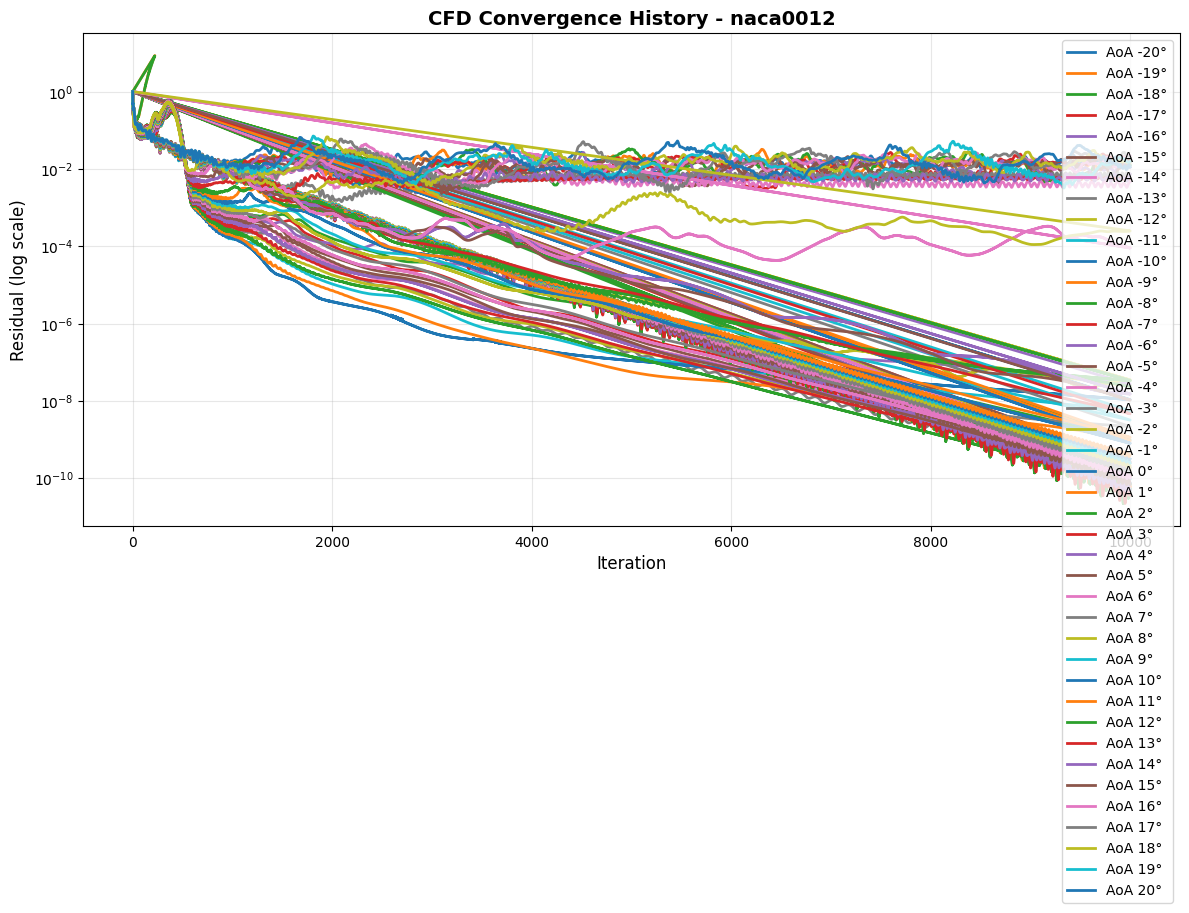

In [10]:
# Check convergence for all angles of attack in a single plot
# Automatically detect AoA folders
profile_dir = f'../{profile}/runs'
aoa_folders = [d for d in os.listdir(profile_dir) if os.path.isdir(os.path.join(profile_dir, d)) and d.startswith('aoa')]

# Extract angle values and sort (handle both positive and negative angles)
aoa_list = []
for folder in aoa_folders:
    # Match aoa-N for negative angles or aoaN for positive angles
    match = re.match(r'aoa(-?\d+)', folder)
    if match:
        aoa_list.append(int(match.group(1)))
aoa_list.sort()

print(f'Found {len(aoa_list)} angle of attack cases: {aoa_list}')

fig, ax = plt.subplots(figsize=(12, 8))

print(f'\nChecking convergence for {profile}')
print('='*60)

for angle in aoa_list:
    stats = pd.read_csv(f'../{profile}/runs/aoa{angle}/stats.csv')
    ax.semilogy(stats['iter'], stats['rho'], label=f'AoA {angle}°', linewidth=2)
    
    # Print convergence info
    initial_residual = stats['rho'].iloc[0]
    final_residual = stats['rho'].iloc[-1]
    reduction = final_residual / initial_residual
    
    status = '✓' if reduction < 1e-4 else '⚠'
    print(f'{status} AoA {angle:2d}°: {initial_residual:.2e} → {final_residual:.2e} (reduction: {reduction:.2e})')

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Residual (log scale)', fontsize=12)
ax.set_title(f'CFD Convergence History - {profile}', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
fig.savefig(f'{profile}/convergence.png', dpi=300)

In [11]:
# Use detected AoA list (assumes previous cell was run)
aoa = np.array(aoa_list)
cl = [extract_cl(f'../{profile}/runs/aoa{a}/force_airfoil.csv', tol=5e-4) for a in aoa]

Warning, cl is not converged : ../naca0012/runs/aoa-20/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa-19/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa-18/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa-17/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa-16/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa-15/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa-14/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa-13/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa13/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa14/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa15/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa16/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa17/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa18/fo

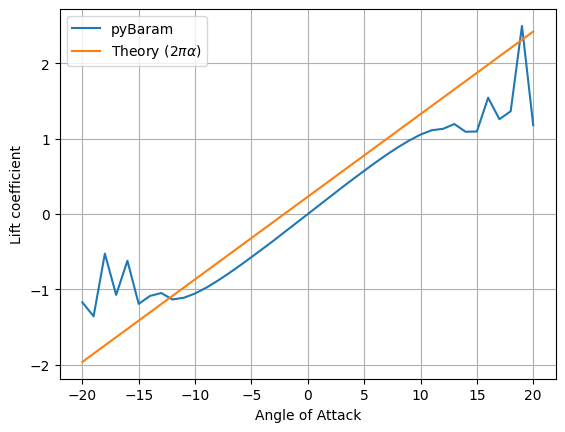

In [12]:
fig, ax = plt.subplots()
ax.plot(aoa, cl)
ax.plot(aoa, 2*np.pi*np.deg2rad(aoa + 2.1))
ax.set_xlabel('Angle of Attack')
ax.set_ylabel('Lift coefficient')
ax.legend(['pyBaram', r'Theory ($2\pi\alpha$)'])
ax.grid()
fig.savefig(f'{profile}/cl.png', dpi=300)